# Results Comparison

Loads summary CSVs from `results/`, keeps only the `Random` sampling runs for `20%`, and compares:

- `orig_model_mw_test_set_accuracy`
- `new_model_orig_test_set_accuracy`
- `new_model_mw_test_set_accuracy`
- `evasions_success_percent`


In [1]:
from pathlib import Path
import os
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'backdoor_attack.py').exists() and (candidate / 'mw_backdoor').is_dir():
            return candidate
    raise RuntimeError('Could not locate repository root containing backdoor_attack.py and mw_backdoor/')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / 'results'
PERCENTAGE_PATTERN = re.compile(r'^\d+%$')
TARGET_METRICS = [
    'orig_model_mw_test_set_accuracy',
    'new_model_orig_test_set_accuracy',
    'new_model_mw_test_set_accuracy',
    'evasions_success_percent',
]

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

print('Repository root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)


Repository root: /Users/falcon/Machine Learning/Severi Data Poisoning Attack
Results dir: /Users/falcon/Machine Learning/Severi Data Poisoning Attack/results


In [2]:
def parse_results_csv(csv_path):
    rel = csv_path.relative_to(RESULTS_DIR)
    parts = rel.parts
    if not parts or not PERCENTAGE_PATTERN.match(parts[0]):
        return None

    percentage_label = parts[0]
    percentage = int(percentage_label[:-1])

    sampling_strategy = 'Random'
    experiment_name = parts[-2]
    if len(parts) >= 4 and not parts[1].startswith('ember__'):
        sampling_strategy = parts[1]

    tokens = experiment_name.split('__')
    if len(tokens) != 5:
        raise ValueError('Unexpected experiment directory name: {}'.format(experiment_name))

    dataset, model_id, feature_selector, value_selector, target_features = tokens
    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')].copy()
    if df.empty:
        return None

    for metric in TARGET_METRICS:
        df[metric] = pd.to_numeric(df[metric], errors='coerce')

    df['results_csv_path'] = str(csv_path)
    df['percentage_label'] = percentage_label
    df['percentage'] = percentage
    df['sampling_strategy'] = sampling_strategy
    df['dataset'] = dataset
    df['model_id'] = model_id
    df['feature_selector'] = feature_selector
    df['value_selector'] = value_selector
    df['target_features'] = target_features
    df['selector_pair'] = feature_selector + ' + ' + value_selector
    return df


all_csv_paths = sorted(RESULTS_DIR.rglob('*__summary_df.csv'))
frames = []
for csv_path in all_csv_paths:
    parsed = parse_results_csv(csv_path)
    if parsed is not None:
        frames.append(parsed)

if not frames:
    raise ValueError('No percentage-based summary CSVs were found in {}'.format(RESULTS_DIR))

all_results_df = pd.concat(frames, ignore_index=True)
all_results_df['sampling_strategy_normalized'] = all_results_df['sampling_strategy'].str.strip().str.casefold()

comparison_df = all_results_df[
    (all_results_df['percentage'] != 20)
    | (all_results_df['sampling_strategy_normalized'] == 'random')
].copy()

comparison_df = comparison_df.sort_values(
    ['percentage', 'feature_selector', 'value_selector']
).reset_index(drop=True)

print('Loaded result rows:', len(all_results_df))
print('Rows used for comparison:', len(comparison_df))
print('Percentages:', sorted(comparison_df['percentage'].unique().tolist()))
print('Selector pairs:', sorted(comparison_df['selector_pair'].unique().tolist()))


Loaded result rows: 45
Rows used for comparison: 24
Percentages: [5, 10, 15, 20, 25, 30, 40, 50]
Selector pairs: ['combined_shap + combined_shap', 'shap_largest_abs + argmin_Nv_sum_abs_shap', 'shap_largest_abs + min_population_new']


In [3]:
comparison_columns = [
    'percentage_label',
    'sampling_strategy',
    'feature_selector',
    'value_selector',
    'selector_pair',
    'num_gw_to_watermark',
    'num_watermark_features',
] + TARGET_METRICS

display(comparison_df[comparison_columns])


,percentage_label,sampling_strategy,feature_selector,value_selector,selector_pair,num_gw_to_watermark,num_watermark_features,orig_model_mw_test_set_accuracy,new_model_orig_test_set_accuracy,new_model_mw_test_set_accuracy,evasions_success_percent
0,5%,Random,combined_shap,combined_shap,combined_shap + combined_shap,150,17,35.005600,0.000000,0.000000,35.005600
1,5%,Random,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,150,17,99.755428,0.000000,0.000000,99.755428
2,5%,Random,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,150,17,90.490479,0.000000,0.000000,90.490479
3,10%,Random,combined_shap,combined_shap,combined_shap + combined_shap,300,17,94.552629,71.334765,10.624480,83.930205
4,10%,Random,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,300,17,99.691716,70.350313,12.289211,87.402505
5,10%,Random,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,300,17,79.420016,70.875423,2.367618,77.216816
6,15%,Random,combined_shap,combined_shap,combined_shap + combined_shap,450,17,92.513847,79.656367,15.428566,77.118165
7,15%,Random,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,450,17,99.691716,83.126612,4.917123,94.774593
8,15%,Random,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,450,17,84.361802,79.786873,0.277455,84.147031
9,20%,Random,combined_shap,combined_shap,combined_shap + combined_shap,600,17,92.513847,87.131216,16.813786,75.741165


In [4]:
summary_df = comparison_df[
    ['percentage', 'selector_pair'] + TARGET_METRICS
].groupby(['percentage', 'selector_pair'], as_index=False).mean(numeric_only=True)

display(summary_df.sort_values(['percentage', 'selector_pair']))


,percentage,selector_pair,orig_model_mw_test_set_accuracy,new_model_orig_test_set_accuracy,new_model_mw_test_set_accuracy,evasions_success_percent
0,5,combined_shap + combined_shap,35.005600,0.000000,0.000000,35.005600
1,5,shap_largest_abs + argmin_Nv_sum_abs_shap,99.755428,0.000000,0.000000,99.755428
2,5,shap_largest_abs + min_population_new,90.490479,0.000000,0.000000,90.490479
3,10,combined_shap + combined_shap,94.552629,71.334765,10.624480,83.930205
4,10,shap_largest_abs + argmin_Nv_sum_abs_shap,99.691716,70.350313,12.289211,87.402505
5,10,shap_largest_abs + min_population_new,79.420016,70.875423,2.367618,77.216816
6,15,combined_shap + combined_shap,92.513847,79.656367,15.428566,77.118165
7,15,shap_largest_abs + argmin_Nv_sum_abs_shap,99.691716,83.126612,4.917123,94.774593
8,15,shap_largest_abs + min_population_new,84.361802,79.786873,0.277455,84.147031
9,20,combined_shap + combined_shap,92.513847,87.131216,16.813786,75.741165


In [5]:
for metric in TARGET_METRICS:
    pivot_df = summary_df.pivot(index='percentage', columns='selector_pair', values=metric).sort_index()
    print('\n' + metric)
    display(pivot_df)



orig_model_mw_test_set_accuracy


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
percentage,,,
5,35.005600,99.755428,90.490479
10,94.552629,99.691716,79.420016
15,92.513847,99.691716,84.361802
20,92.513847,99.691716,84.361802
25,92.513847,99.687606,85.554859
30,92.513847,99.687606,85.402772
40,91.449241,99.687606,79.123036
50,91.449241,99.691716,77.121248



new_model_orig_test_set_accuracy


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
percentage,,,
5,0.000000,0.000000,0.000000
10,71.334765,70.350313,70.875423
15,79.656367,83.126612,79.786873
20,87.131216,85.099627,88.281114
25,89.011746,89.601595,89.562546
30,90.845005,90.618931,90.116428
40,91.556113,90.822398,92.154183
50,90.424712,92.628940,91.910639



new_model_mw_test_set_accuracy


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
percentage,,,
5,0.000000,0.000000,0.000000
10,10.624480,12.289211,2.367618
15,15.428566,4.917123,0.277455
20,16.813786,10.801229,0.532303
25,18.826878,8.389424,0.279510
30,13.096914,4.598563,0.407962
40,20.227513,11.057104,0.425431
50,16.493172,12.415607,0.242516



evasions_success_percent


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
percentage,,,
5,35.005600,99.755428,90.490479
10,83.930205,87.402505,77.216816
15,77.118165,94.774593,84.147031
20,75.741165,88.890487,83.831554
25,73.750681,91.298182,85.278431
30,79.524832,95.089043,85.003031
40,71.275164,88.630502,78.701715
50,75.110211,87.276109,76.881814


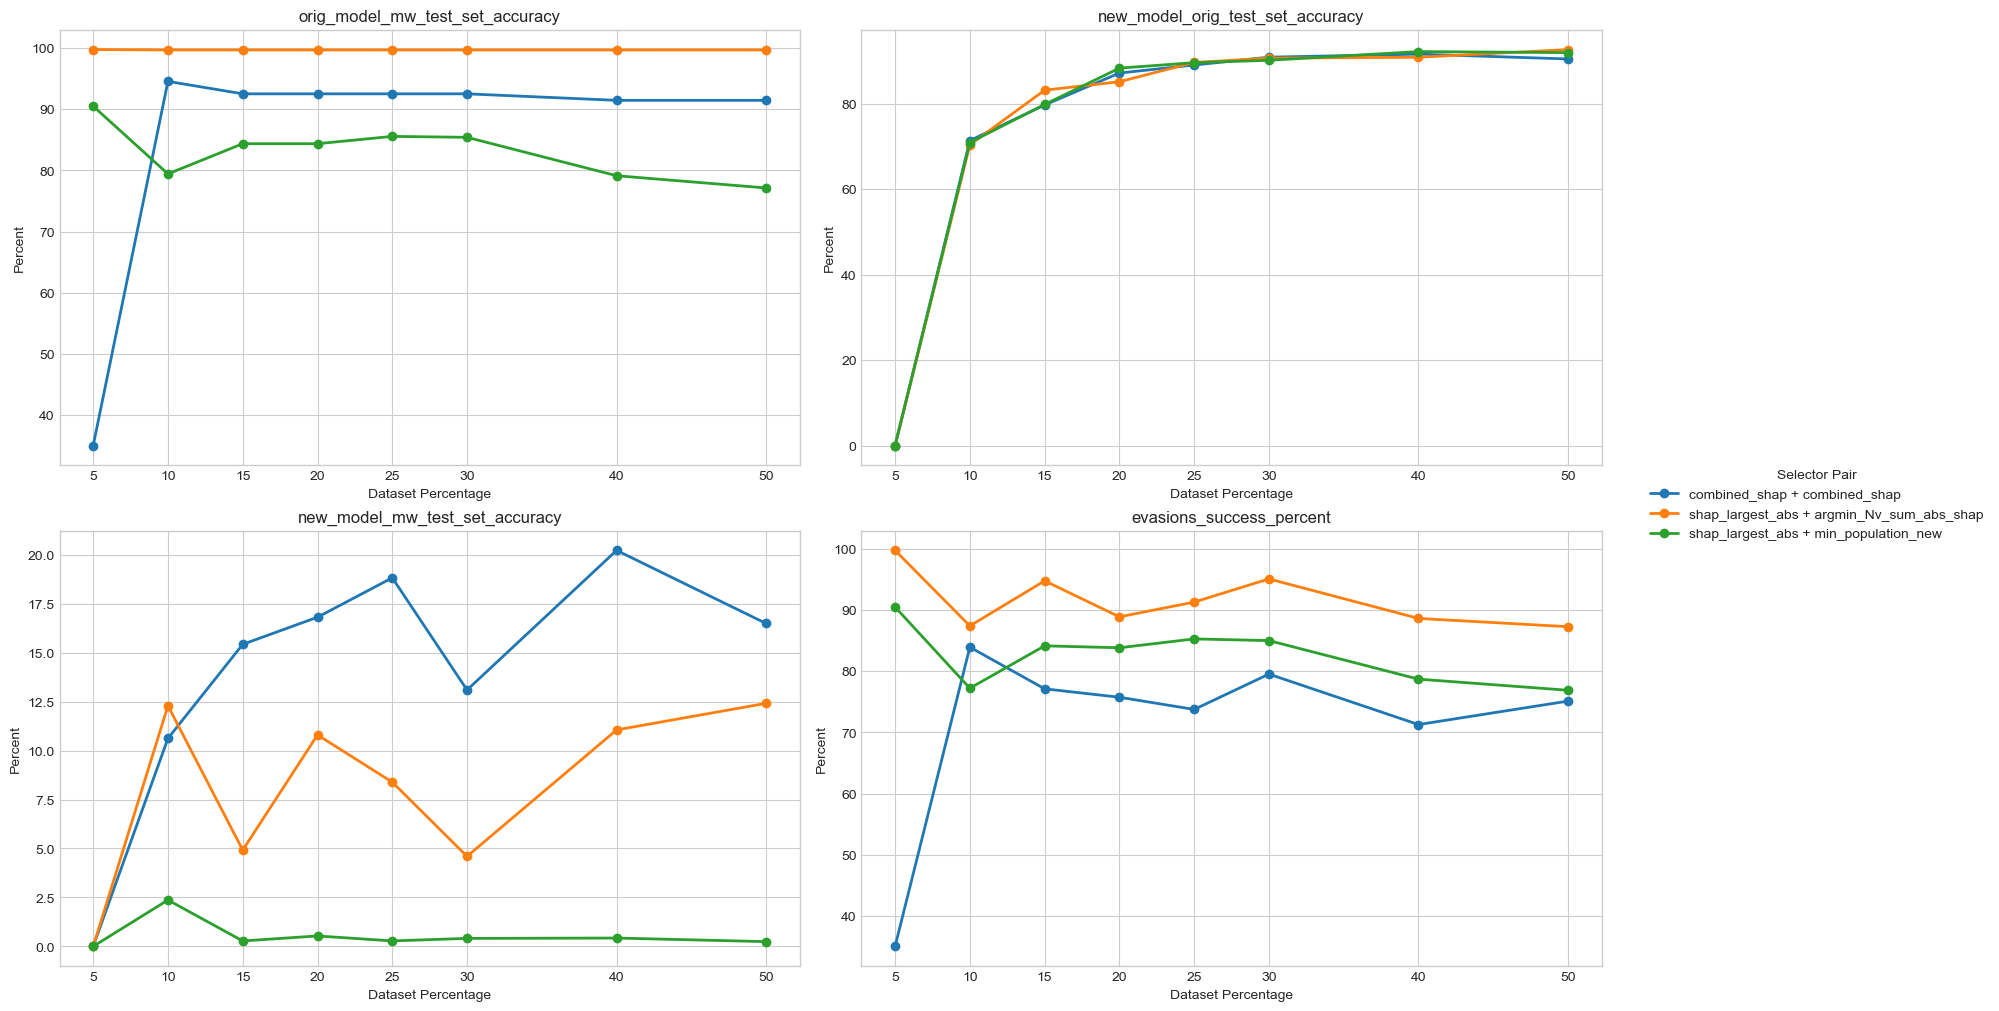

In [6]:
selector_order = sorted(summary_df['selector_pair'].unique().tolist())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes = axes.flatten()

for ax, metric in zip(axes, TARGET_METRICS):
    for selector_pair in selector_order:
        metric_df = summary_df[summary_df['selector_pair'] == selector_pair].sort_values('percentage')
        ax.plot(
            metric_df['percentage'],
            metric_df[metric],
            marker='o',
            linewidth=2,
            label=selector_pair,
        )
    ax.set_title(metric)
    ax.set_xlabel('Dataset Percentage')
    ax.set_ylabel('Percent')
    ax.set_xticks(sorted(summary_df['percentage'].unique().tolist()))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), title='Selector Pair')
plt.show()


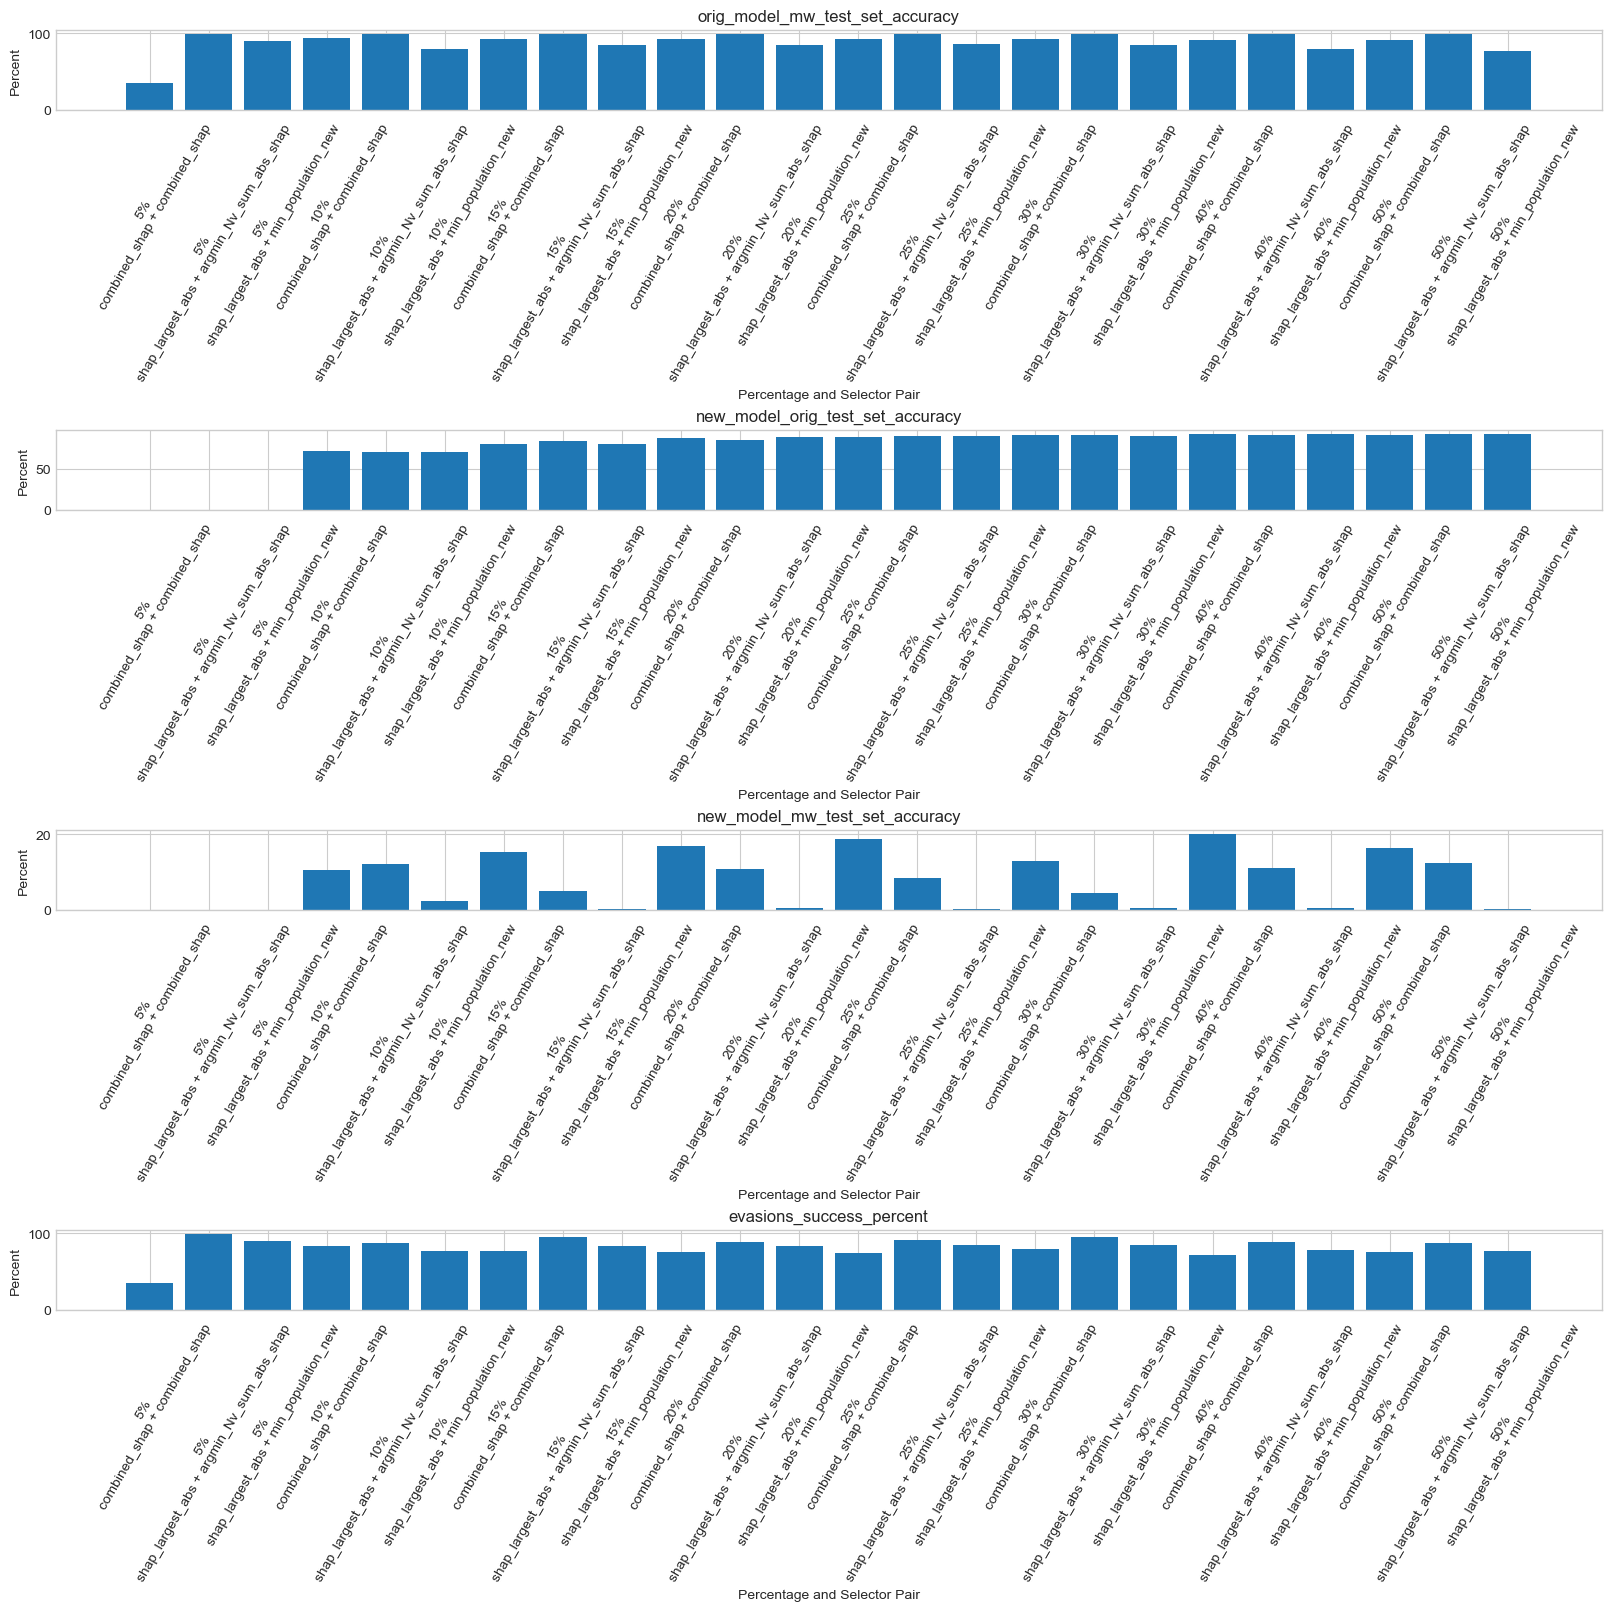

In [7]:
fig, axes = plt.subplots(len(TARGET_METRICS), 1, figsize=(16, 4 * len(TARGET_METRICS)), constrained_layout=True)
if len(TARGET_METRICS) == 1:
    axes = [axes]

plot_df = summary_df.copy()
plot_df['x_label'] = plot_df['percentage'].astype(str) + '%\n' + plot_df['selector_pair']

for ax, metric in zip(axes, TARGET_METRICS):
    metric_df = plot_df.sort_values(['percentage', 'selector_pair'])
    ax.bar(metric_df['x_label'], metric_df[metric])
    ax.set_title(metric)
    ax.set_xlabel('Percentage and Selector Pair')
    ax.set_ylabel('Percent')
    ax.tick_params(axis='x', rotation=60)

plt.show()


## 20% Sampling Strategy Comparison

This section uses only the `20%` folder and compares all available sampling strategies for each feat-value selector pair.


In [8]:
sampling_comparison_df = all_results_df[all_results_df['percentage'] == 20].copy()
if sampling_comparison_df.empty:
    raise ValueError('No 20% sampling-strategy results were found in {}'.format(RESULTS_DIR))

sampling_order = sorted(
    sampling_comparison_df['sampling_strategy'].unique().tolist(),
    key=lambda value: (value.strip().casefold() != 'random', value.casefold()),
)
selector_pair_order_20 = sorted(sampling_comparison_df['selector_pair'].unique().tolist())
sampling_comparison_df['sampling_strategy'] = pd.Categorical(
    sampling_comparison_df['sampling_strategy'],
    categories=sampling_order,
    ordered=True,
)
sampling_comparison_df['selector_pair'] = pd.Categorical(
    sampling_comparison_df['selector_pair'],
    categories=selector_pair_order_20,
    ordered=True,
)
sampling_comparison_df = sampling_comparison_df.sort_values(
    ['sampling_strategy', 'feature_selector', 'value_selector']
).reset_index(drop=True)

print('20% rows:', len(sampling_comparison_df))
print('Sampling strategies:', sampling_order)
print('Selector pairs:', selector_pair_order_20)


20% rows: 24
Sampling strategies: ['Random', 'Cosine Similarity', 'Distribution_Based', 'Featured-Based', 'Jaccard', 'Mahalanobis', 'Shap Contribution Based', 'Wasserstein']
Selector pairs: ['combined_shap + combined_shap', 'shap_largest_abs + argmin_Nv_sum_abs_shap', 'shap_largest_abs + min_population_new']


In [21]:
sampling_comparison_df.iloc[:, 18][0]

'/Users/falcon/Machine Learning/Severi Data Poisoning Attack/results/20%/Random/ember__lightgbm__combined_shap__combined_shap__feasible/ember__lightgbm__combined_shap__combined_shap__feasible__summary_df.csv'

In [9]:
display(sampling_comparison_df[comparison_columns])


,percentage_label,sampling_strategy,feature_selector,value_selector,selector_pair,num_gw_to_watermark,num_watermark_features,orig_model_mw_test_set_accuracy,new_model_orig_test_set_accuracy,new_model_mw_test_set_accuracy,evasions_success_percent
0,20%,Random,combined_shap,combined_shap,combined_shap + combined_shap,600,17,92.513847,87.131216,16.813786,75.741165
1,20%,Random,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,600,17,99.691716,85.099627,10.801229,88.890487
2,20%,Random,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,600,17,84.361802,88.281114,0.532303,83.831554
3,20%,Cosine Similarity,combined_shap,combined_shap,combined_shap + combined_shap,600,17,92.513847,81.867787,12.205975,80.324314
4,20%,Cosine Similarity,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,600,17,99.691716,84.033993,4.690021,95.001696
5,20%,Cosine Similarity,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,600,17,84.361802,87.730314,0.331919,84.043242
6,20%,Distribution_Based,combined_shap,combined_shap,combined_shap + combined_shap,600,17,92.513847,88.443476,4.820528,87.700513
7,20%,Distribution_Based,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,600,17,99.691716,85.984401,1.035833,98.655884
8,20%,Distribution_Based,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,600,17,84.361802,88.582204,0.094540,84.267261
9,20%,Featured-Based,combined_shap,combined_shap,combined_shap + combined_shap,600,17,92.513847,86.087162,6.256101,86.261856


In [10]:
sampling_summary_df = sampling_comparison_df[
    ['sampling_strategy', 'selector_pair'] + TARGET_METRICS
].groupby(['sampling_strategy', 'selector_pair'], as_index=False).mean(numeric_only=True)

sampling_summary_df['sampling_strategy'] = pd.Categorical(
    sampling_summary_df['sampling_strategy'],
    categories=sampling_order,
    ordered=True,
)
sampling_summary_df['selector_pair'] = pd.Categorical(
    sampling_summary_df['selector_pair'],
    categories=selector_pair_order_20,
    ordered=True,
)
sampling_summary_df = sampling_summary_df.sort_values(['sampling_strategy', 'selector_pair']).reset_index(drop=True)

display(sampling_summary_df)


/var/folders/3c/yt5ph8rx5ys35wwk0np323bc0000gn/T/ipykernel_60397/840926903.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby(['sampling_strategy', 'selector_pair'], as_index=False).mean(numeric_only=True)


,sampling_strategy,selector_pair,orig_model_mw_test_set_accuracy,new_model_orig_test_set_accuracy,new_model_mw_test_set_accuracy,evasions_success_percent
0,Random,combined_shap + combined_shap,92.513847,87.131216,16.813786,75.741165
1,Random,shap_largest_abs + argmin_Nv_sum_abs_shap,99.691716,85.099627,10.801229,88.890487
2,Random,shap_largest_abs + min_population_new,84.361802,88.281114,0.532303,83.831554
3,Cosine Similarity,combined_shap + combined_shap,92.513847,81.867787,12.205975,80.324314
4,Cosine Similarity,shap_largest_abs + argmin_Nv_sum_abs_shap,99.691716,84.033993,4.690021,95.001696
5,Cosine Similarity,shap_largest_abs + min_population_new,84.361802,87.730314,0.331919,84.043242
6,Featured-Based,combined_shap + combined_shap,92.513847,86.087162,6.256101,86.261856
7,Featured-Based,shap_largest_abs + argmin_Nv_sum_abs_shap,99.691716,87.264805,3.091057,96.600660
8,Featured-Based,shap_largest_abs + min_population_new,84.361802,87.568978,0.348360,84.018579
9,Jaccard,combined_shap + combined_shap,92.513847,83.470862,13.217145,79.308006


In [11]:
for metric in TARGET_METRICS:
    pivot_df = sampling_summary_df.pivot(index='sampling_strategy', columns='selector_pair', values=metric)
    pivot_df = pivot_df.reindex(index=sampling_order, columns=selector_pair_order_20)
    print('\n20% sampling comparison - ' + metric)
    display(pivot_df)



20% sampling comparison - orig_model_mw_test_set_accuracy


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
Random,92.513847,99.691716,84.361802
Cosine Similarity,92.513847,99.691716,84.361802
Featured-Based,92.513847,99.691716,84.361802
Jaccard,92.513847,99.691716,84.361802
Mahalanobis,92.513847,99.691716,84.361802



20% sampling comparison - new_model_orig_test_set_accuracy


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
Random,87.131216,85.099627,88.281114
Cosine Similarity,81.867787,84.033993,87.730314
Featured-Based,86.087162,87.264805,87.568978
Jaccard,83.470862,81.171067,84.876635
Mahalanobis,88.074564,82.765920,84.589931



20% sampling comparison - new_model_mw_test_set_accuracy


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
Random,16.813786,10.801229,0.532303
Cosine Similarity,12.205975,4.690021,0.331919
Featured-Based,6.256101,3.091057,0.348360
Jaccard,13.217145,8.372982,0.237378
Mahalanobis,10.776566,10.370660,0.668975



20% sampling comparison - evasions_success_percent


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
Random,75.741165,88.890487,83.831554
Cosine Similarity,80.324314,95.001696,84.043242
Featured-Based,86.261856,96.600660,84.018579
Jaccard,79.308006,91.318734,84.126478
Mahalanobis,81.754750,89.321057,83.767842


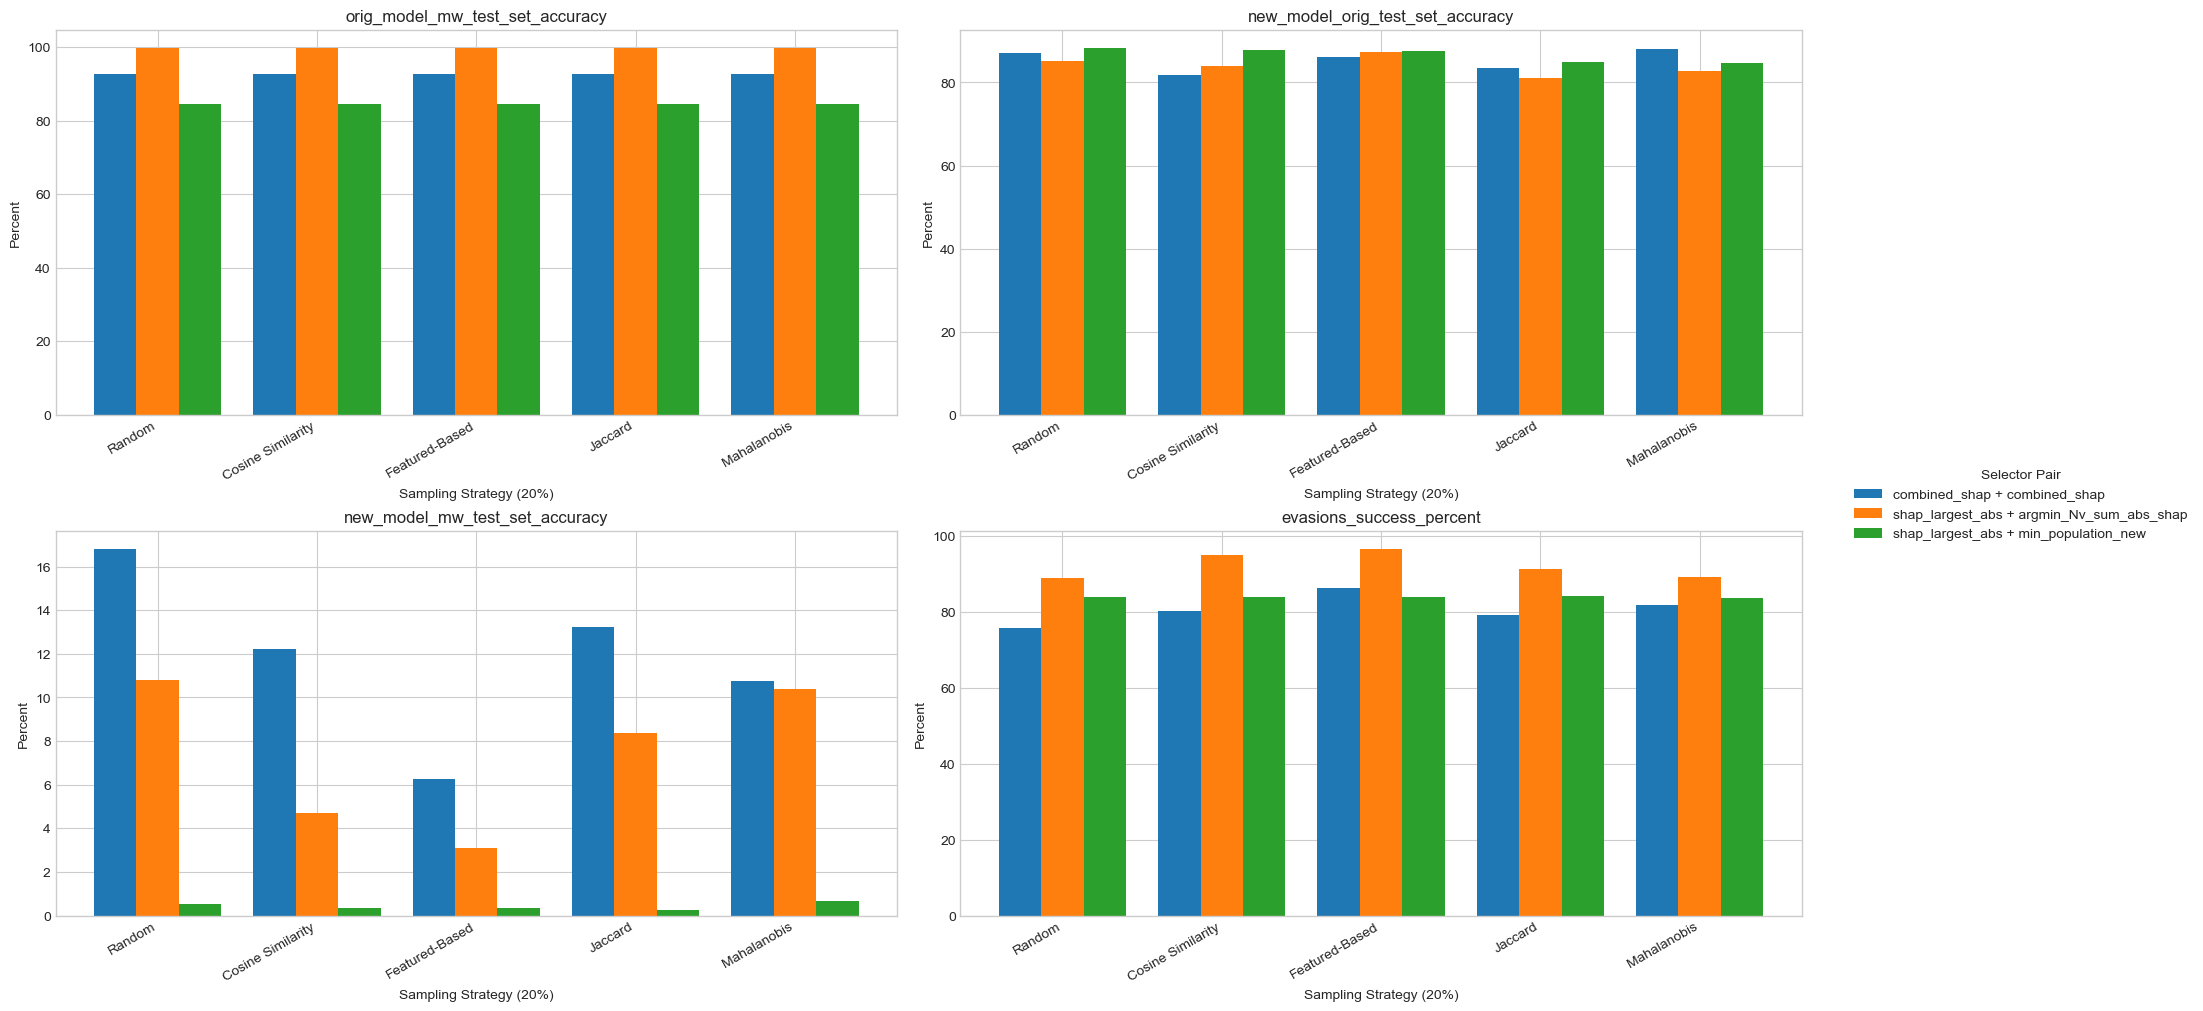

In [14]:
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()
x = np.arange(len(sampling_order))
width = 0.8 / max(1, len(selector_pair_order_20))

for ax, metric in zip(axes, TARGET_METRICS):
    for idx, selector_pair in enumerate(selector_pair_order_20):
        metric_df = sampling_summary_df[sampling_summary_df['selector_pair'] == selector_pair]
        metric_df = metric_df.set_index('sampling_strategy').reindex(sampling_order)
        offsets = x + (idx - (len(selector_pair_order_20) - 1) / 2.0) * width
        ax.bar(offsets, metric_df[metric], width=width, label=selector_pair)
    ax.set_title(metric)
    ax.set_xlabel('Sampling Strategy (20%)')
    ax.set_ylabel('Percent')
    ax.set_xticks(x)
    ax.set_xticklabels(sampling_order, rotation=30, ha='right')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), title='Selector Pair')
plt.show()


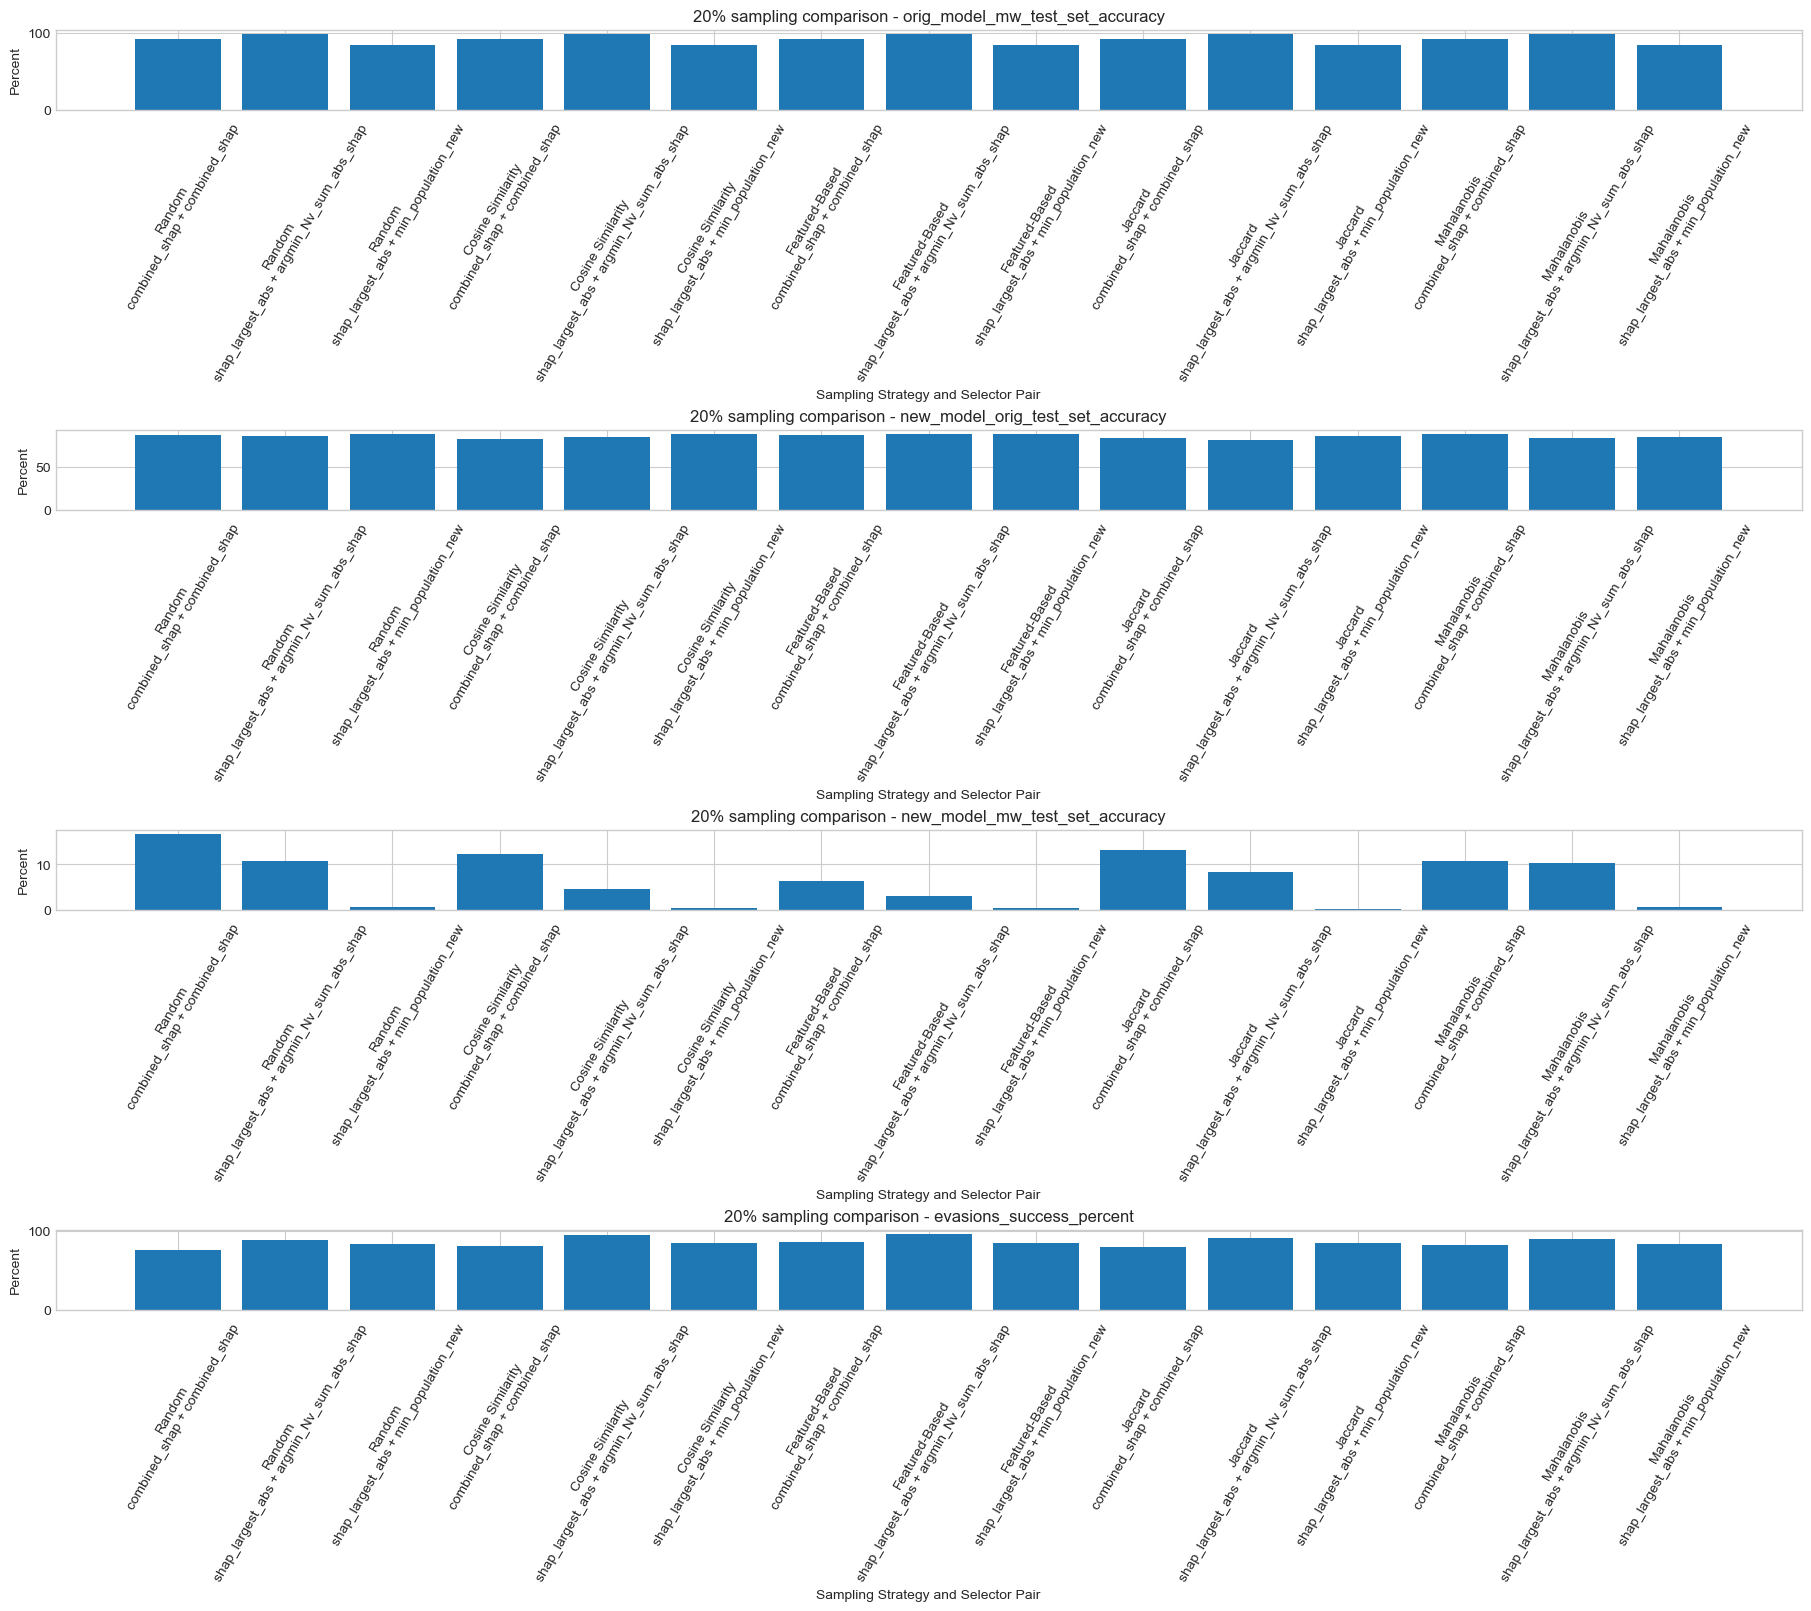

In [15]:
fig, axes = plt.subplots(len(TARGET_METRICS), 1, figsize=(18, 4 * len(TARGET_METRICS)), constrained_layout=True)
if len(TARGET_METRICS) == 1:
    axes = [axes]

sampling_plot_df = sampling_summary_df.copy()
sampling_plot_df['x_label'] = sampling_plot_df['sampling_strategy'].astype(str) + '\n' + sampling_plot_df['selector_pair'].astype(str)

for ax, metric in zip(axes, TARGET_METRICS):
    metric_df = sampling_plot_df.sort_values(['sampling_strategy', 'selector_pair'])
    ax.bar(metric_df['x_label'], metric_df[metric])
    ax.set_title('20% sampling comparison - ' + metric)
    ax.set_xlabel('Sampling Strategy and Selector Pair')
    ax.set_ylabel('Percent')
    ax.tick_params(axis='x', rotation=60)

plt.show()
